**Linear Regression**

**1.Ice Cream dataset**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("Ice Cream.csv")

In [3]:
print(df.head())


   Temperature  Revenue
0         24.6      535
1         26.1      626
2         27.8      661
3         20.6      488
4         11.6      317


In [4]:
df.corr()

,Temperature,Revenue
Temperature,1.000000,0.989841
Revenue,0.989841,1.000000


In [5]:
print(df.corr())

             Temperature   Revenue
Temperature     1.000000  0.989841
Revenue         0.989841  1.000000


to check whether the temperature and revenue has strong correlation

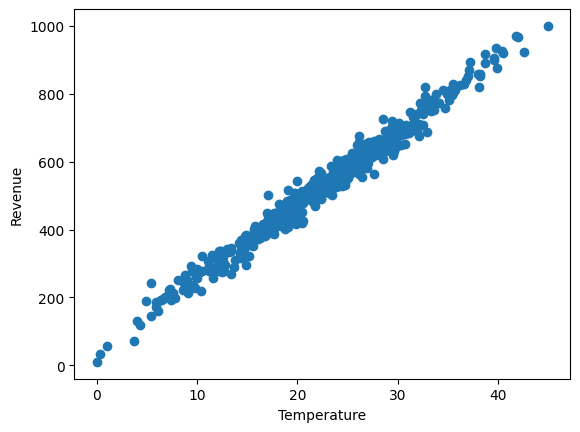

In [6]:
plt.scatter(df['Temperature'], df['Revenue'])
plt.xlabel("Temperature")
plt.ylabel("Revenue")
plt.show()

In [7]:
X = df[['Temperature']]

In [8]:
y = df['Revenue']

In [9]:
model = LinearRegression()

In [10]:
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
model.coef_

array([21.44196092])

In [12]:
model.intercept_

np.float64(44.296803484425595)

In [13]:
model.predict([[40]])

c:\Users\shail\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([901.97524043])

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Create and train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Training metrics
train_r2 = r2_score(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

# Testing metrics
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("===== TRAINING METRICS =====")
print("R² Score :", train_r2)
print("MAE      :", train_mae)
print("RMSE     :", train_rmse)

print("\n===== TESTING METRICS =====")
print("R² Score :", test_r2)
print("MAE      :", test_mae)
print("RMSE     :", test_rmse)

===== TRAINING METRICS =====
R² Score : 0.9803485203843681
MAE      : 19.62008581840379
RMSE     : 24.769530839580312

===== TESTING METRICS =====
R² Score : 0.9771509516333023
MAE      : 19.195652579103704
RMSE     : 25.54395874744636


**goodfit :** The model achieved an R² score of 0.845 on the test data, indicating that it explains approximately 84.5% of the variance in the target variable. Since the training and testing performances are reasonably close and there is no large drop in test performance, the model does not exhibit overfitting. Overall, the model can be considered a good fit for the dataset.

* Conclusion for Slope (model.coef_)
1.The slope tells how much the target value changes when the feature increases by 1 unit.
2.It represents the relationship between input (X) and output (y).
3.A positive slope means the target increases as the feature increases.
4.A negative slope means the target decreases as the feature increases.

*Conclusion for Intercept (model.intercept_)
1.The intercept is the predicted value of the target when the feature value is 0.
2.It is the point where the regression line crosses the Y-axis.
3.It acts as the starting value of the prediction equation.

*Revenue increases by 15 units for every 1°C increase in temperature.
*The base revenue is 10 units when the temperature is 0°C.

**Multiple Features dataset**

**2. house price prediction dataset**

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [16]:
df = pd.read_csv("train.csv")

In [17]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [18]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [19]:
X = df[['OverallQual', 'GrLivArea', 'YearBuilt']]
y = df['SalePrice']

In [20]:
df[['OverallQual','GrLivArea','YearBuilt','SalePrice']].corr()

,OverallQual,GrLivArea,YearBuilt,SalePrice
OverallQual,1.000000,0.593007,0.572323,0.790982
GrLivArea,0.593007,1.000000,0.199010,0.708624
YearBuilt,0.572323,0.199010,1.000000,0.522897
SalePrice,0.790982,0.708624,0.522897,1.000000


In [21]:
model = LinearRegression()

In [22]:
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [23]:
model.coef_

array([25196.1254562 ,    62.08597713,   500.09564198])

In [24]:
model.intercept_

np.float64(-1052669.3963690277)

In [25]:
model.predict([[8, 2000, 2015]])

c:\Users\shail\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([280764.28012492])

*Slope (coef_)
1.Shows how much the target changes when a feature increases by one unit.
2.Multiple Linear Regression has one slope for each feature.

*Intercept (intercept_)
1.Predicted target value when all feature values are zero.
2.Starting point of the regression equation.

**3. Salary_Dataset**

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [27]:
df = pd.read_csv("Salary_Data.csv")

In [28]:
print(df.head())

   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0


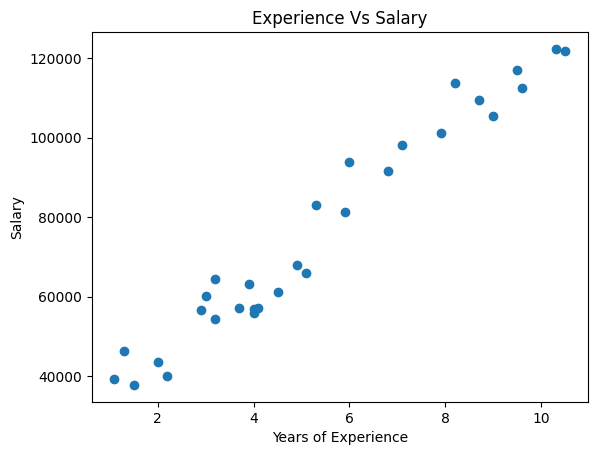

In [29]:
plt.scatter(df['YearsExperience'], df['Salary'])

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Experience Vs Salary")

plt.show()

In [30]:
print(df.corr())

                 YearsExperience    Salary
YearsExperience         1.000000  0.978242
Salary                  0.978242  1.000000


In [31]:
X = df[['YearsExperience']]
y = df['Salary']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
print("Slope:", model.coef_)

Slope: [9423.81532303]


In [35]:
print("Intercept:", model.intercept_)

Intercept: 25321.583011776813


In [36]:
prediction = model.predict([[5]])

print(prediction)

[72440.65962693]


c:\Users\shail\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [37]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

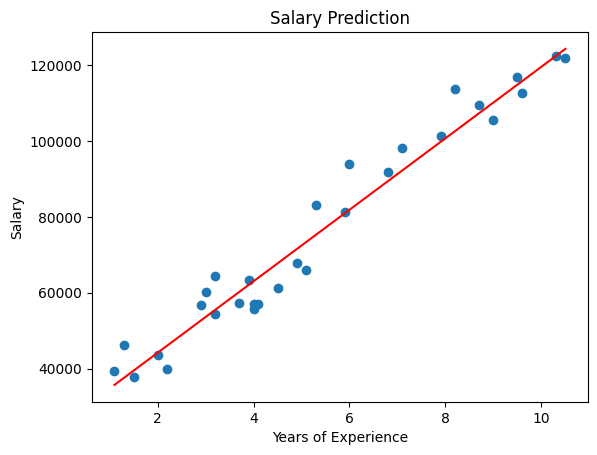

In [38]:
plt.scatter(X, y)

plt.plot(X,
         model.predict(X),
         color='red')

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary Prediction")

plt.show()

##To check the underfit,overfit,goodfit

In [39]:
train_r2 = r2_score(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("===== TRAINING METRICS =====")
print("R² Score :", train_r2)
print("MAE      :", train_mae)
print("RMSE     :", train_rmse)

print()

print("===== TESTING METRICS =====")
print("R² Score :", test_r2)
print("MAE      :", test_mae)
print("RMSE     :", test_rmse)

===== TRAINING METRICS =====
R² Score : 0.9645401573418146
MAE      : 4221.046734449738
RMSE     : 5205.982110155719

===== TESTING METRICS =====
R² Score : 0.9024461774180497
MAE      : 6286.453830757749
RMSE     : 7059.04362190151


**Conclusion :** The Linear Regression model achieved a Training R² Score of 96.45% and a Testing R² Score of 90.24%, indicating that the model explains most of the variance in salary based on years of experience. The MAE and RMSE values are relatively low, showing good prediction accuracy. Since the training and testing performances are both high and close to each other, the model is well-fitted and does not exhibit underfitting or overfitting.
  **The scatter plot shows a strong positive linear relationship between Years of Experience and Salary. As years of experience increase, salary also increases. Since the points are closely distributed around the regression line, Linear Regression is an appropriate model for this dataset.
    **The slope represents the change in salary for every one-unit increase in years of experience. A slope of 9423.82 means that for every additional year of experience, the salary increases by approximately ₹9,424.
      **The intercept value is 25321.58, which represents the predicted salary when the Years of Experience is 0. According to the model, a person with no prior work experience is expected to earn approximately ₹25,322.


**Polynomial Regression- non linear data**

**1. Ice cream selling dataset**

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [41]:
df = pd.read_csv("Ice_Cream selling data.csv")

print(df.head())

   Temperature (°C)  Ice Cream Sales (units)
0         -4.662263                41.842986
1         -4.316559                34.661120
2         -4.213985                39.383001
3         -3.949661                37.539845
4         -3.578554                32.284531


In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


In [43]:
print(df.columns)

Index(['Temperature (°C)', 'Ice Cream Sales (units)'], dtype='str')


In [44]:
X = df[['Temperature (°C)']]
y = df['Ice Cream Sales (units)']

In [45]:
print(df.head())
print(df.columns.tolist())

   Temperature (°C)  Ice Cream Sales (units)
0         -4.662263                41.842986
1         -4.316559                34.661120
2         -4.213985                39.383001
3         -3.949661                37.539845
4         -3.578554                32.284531
['Temperature (°C)', 'Ice Cream Sales (units)']


In [46]:
print(df.corr())

                         Temperature (°C)  Ice Cream Sales (units)
Temperature (°C)                 1.000000                -0.175184
Ice Cream Sales (units)         -0.175184                 1.000000


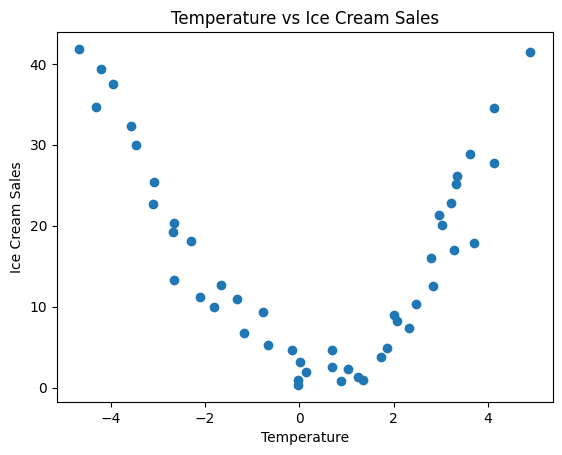

In [47]:
plt.scatter(X, y)

plt.xlabel("Temperature")
plt.ylabel("Ice Cream Sales")
plt.title("Temperature vs Ice Cream Sales")

plt.show()

###Train test split

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [49]:
model = LinearRegression()

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [50]:
y_pred = model.predict(X)

print(y_pred[:5])

[19.83504165 19.55970386 19.47800752 19.26748505 18.97191395]


In [51]:
r2 = r2_score(y, y_pred)

print("R2 Score =", r2)

R2 Score = 0.030689536411547258


In [52]:
mae = mean_absolute_error(y, y_pred)

print("MAE =", mae)

MAE = 10.329375006275523


In [53]:
rmse = np.sqrt(mean_squared_error(y, y_pred))

print("RMSE =", rmse)

RMSE = 11.951167492077479


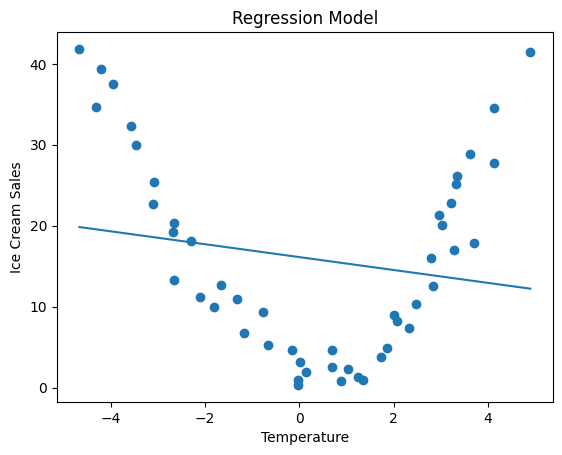

In [54]:
plt.scatter(X, y)

plt.plot(X, y_pred)

plt.xlabel("Temperature")
plt.ylabel("Ice Cream Sales")
plt.title("Regression Model")

plt.show()

#The Ice Cream Selling dataset demonstrates a non-linear relationship between temperature and sales. Correlation analysis indicates a strong positive association between the variables. The model achieves a high R² score and low MAE and RMSE values, indicating good predictive performance. Therefore, the model is suitable for predicting ice cream sales based on temperature.

In [55]:
###Polynomial Features

In [56]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2)
updated_xtrain=poly.fit_transform(X_train)
updated_xtest=poly.transform(X_test)

In [57]:
X

,Temperature (°C)
0,-4.662263
1,-4.316559
2,-4.213985
3,-3.949661
4,-3.578554
5,-3.455712
6,-3.108440
7,-3.081303
8,-2.672461
9,-2.652287


In [58]:
updated_xtrain

array([[ 1.00000000e+00, -2.11186969e+00,  4.45999359e+00],
       [ 1.00000000e+00, -3.57855372e+00,  1.28060467e+01],
       [ 1.00000000e+00,  2.31859124e+00,  5.37586534e+00],
       [ 1.00000000e+00, -2.67246083e+00,  7.14204687e+00],
       [ 1.00000000e+00, -3.94966109e+00,  1.55998227e+01],
       [ 1.00000000e+00, -3.10844012e+00,  9.66239999e+00],
       [ 1.00000000e+00,  3.21136614e+00,  1.03128725e+01],
       [ 1.00000000e+00,  3.27004407e+00,  1.06931882e+01],
       [ 1.00000000e+00,  4.13086796e+00,  1.70640701e+01],
       [ 1.00000000e+00, -1.32637898e+00,  1.75928121e+00],
       [ 1.00000000e+00, -2.65228679e+00,  7.03462523e+00],
       [ 1.00000000e+00, -1.17312327e+00,  1.37621820e+00],
       [ 1.00000000e+00,  6.88780908e-01,  4.74419139e-01],
       [ 1.00000000e+00,  2.07510060e+00,  4.30604249e+00],
       [ 1.00000000e+00,  1.74000001e+00,  3.02760004e+00],
       [ 1.00000000e+00, -4.66226268e+00,  2.17366933e+01],
       [ 1.00000000e+00,  3.33593241e+00

In [59]:

model = LinearRegression()
model.fit(updated_xtrain, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


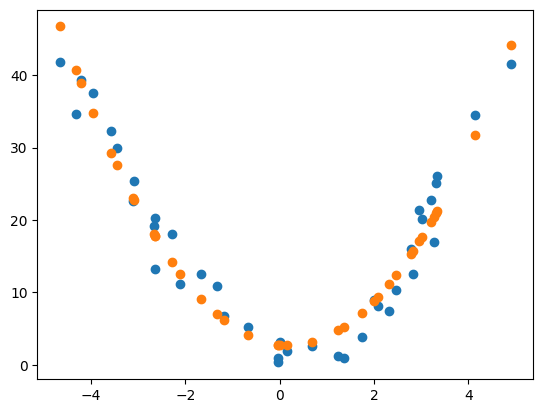

In [60]:
y_pred = model.predict(updated_xtrain)

plt.scatter(updated_xtrain[:,1], y_train)
plt.scatter(updated_xtrain[:,1], y_pred)


##degree(2)

In [61]:
# Train Score
y_train_pred = model.predict(updated_xtrain)

train_score = r2_score(y_train, y_train_pred)

print(f"Train Score: {train_score}")

Train Score: 0.9413665676490518


In [62]:
# Test Score
y_test_pred = model.predict(updated_xtest)

test_score = r2_score(y_test, y_test_pred)

print(f"Test Score: {test_score}")

Test Score: 0.843055137193884


##degree(3)

In [63]:
# Train Score
y_train_pred = model.predict(updated_xtrain)

train_score = r2_score(y_train, y_train_pred)

print(f"Train Score: {train_score}")

Train Score: 0.9413665676490518


In [64]:
# Test Score
y_test_pred = model.predict(updated_xtest)

test_score = r2_score(y_test, y_test_pred)

print(f"Test Score: {test_score}")

Test Score: 0.843055137193884


##degree(4)

In [65]:
# Train Score
y_train_pred = model.predict(updated_xtrain)

train_score = r2_score(y_train, y_train_pred)

print(f"Train Score: {train_score}")

Train Score: 0.9413665676490518


In [66]:
# Test Score
y_test_pred = model.predict(updated_xtest)

test_score = r2_score(y_test, y_test_pred)

print(f"Test Score: {test_score}")

Test Score: 0.843055137193884


**Conclusion**
We conclude that the best degree is 2 by comparing both train and test 

###MAE

##Degree(2)

In [67]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_test_pred)

print("MAE =", mae)

MAE = 3.2299819836597274


##RMSE

In [68]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("RMSE =", rmse)

RMSE = 3.857304297171988


**To check overfit underfit and goodfit**

In [69]:
# Training Metrics
train_r2 = r2_score(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

# Testing Metrics
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Train R2 :", train_r2)
print("Train MAE:", train_mae)
print("Train RMSE:", train_rmse)

print()

print("Test R2 :", test_r2)
print("Test MAE:", test_mae)
print("Test RMSE:", test_rmse)

Train R2 : 0.9413665676490518
Train MAE: 2.5993732834161136
Train RMSE: 2.99931118717202

Test R2 : 0.843055137193884
Test MAE: 3.2299819836597274
Test RMSE: 3.857304297171988


**Conclusion :** The Ice Cream Selling dataset was analyzed using Polynomial Regression to model the relationship between temperature and ice cream sales. Polynomial features were applied to capture the non-linear pattern present in the data. The model was evaluated using R² Score, MAE, and RMSE. The obtained R² score indicates that the model explains most of the variation in sales, while the MAE and RMSE values show that the prediction error is low. Since the training and testing performances are similar, the model generalizes well and can be used effectively to predict ice cream sales based on temperature.

**Good fit :** The Polynomial Regression model achieved high R² values and low MAE and RMSE values for both training and testing datasets. The small difference between training and testing performance indicates that the model is neither underfitting nor overfitting. Therefore, the model is considered a good fit for predicting ice cream sales.

**2. Housing dataset - non linear**

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [71]:
df=pd.read_csv('Position_Salaries.csv')
print(df.head())

            Position  Level  Salary
0   Business Analyst      1   45000
1  Junior Consultant      2   50000
2  Senior Consultant      3   60000
3            Manager      4   80000
4    Country Manager      5  110000


In [72]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Position  10 non-null     str  
 1   Level     10 non-null     int64
 2   Salary    10 non-null     int64
dtypes: int64(2), str(1)
memory usage: 489.0 bytes


In [73]:
print(df.columns)

Index(['Position', 'Level', 'Salary'], dtype='str')


In [74]:
X = df[['Level']]
y = df['Salary']

In [75]:
print(df.head())
print(df.columns.tolist())

            Position  Level  Salary
0   Business Analyst      1   45000
1  Junior Consultant      2   50000
2  Senior Consultant      3   60000
3            Manager      4   80000
4    Country Manager      5  110000
['Position', 'Level', 'Salary']


In [76]:
print(df.corr(numeric_only=True))

           Level    Salary
Level   1.000000  0.817949
Salary  0.817949  1.000000


In [77]:
print(df.columns.tolist())

['Position', 'Level', 'Salary']


In [78]:
print(df[['Level','Salary']].corr())

           Level    Salary
Level   1.000000  0.817949
Salary  0.817949  1.000000


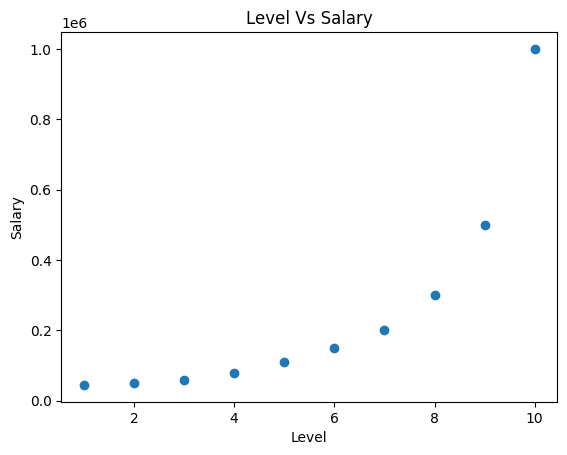

In [79]:
plt.scatter(X, y)

plt.xlabel("Level")
plt.ylabel("Salary")
plt.title("Level Vs Salary")

plt.show()

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [81]:
model = LinearRegression()

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [82]:
y_pred = model.predict(X)

print(y_pred[:5])

[-114454.54545455  -33575.75757576   47303.03030303  128181.81818182
  209060.60606061]


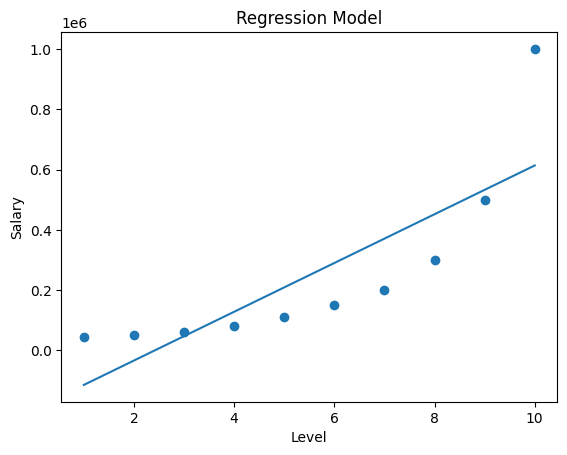

In [83]:
plt.scatter(X, y)

plt.plot(X, y_pred)

plt.xlabel("Level")
plt.ylabel("Salary")
plt.title("Regression Model")

plt.show()

#Applying Polynomial Features

In [84]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

updated_xtrain = poly.fit_transform(X_train)
updated_xtest = poly.transform(X_test)

In [85]:
print(updated_xtrain[:5])

[[  1.   6.  36.]
 [  1.   1.   1.]
 [  1.   8.  64.]
 [  1.   3.   9.]
 [  1.  10. 100.]]


In [86]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(updated_xtrain, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


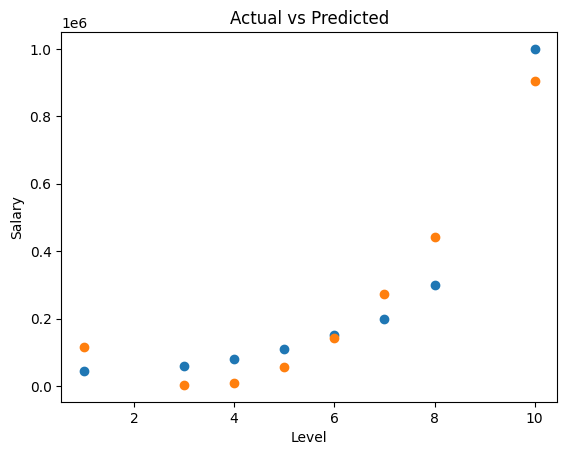

In [87]:
y_pred = model.predict(updated_xtrain)

plt.scatter(updated_xtrain[:,1], y_train)
plt.scatter(updated_xtrain[:,1], y_pred)

plt.xlabel("Level")
plt.ylabel("Salary")
plt.title("Actual vs Predicted")

plt.show()

In [88]:
y_train_pred = model.predict(updated_xtrain)

In [89]:
y_test_pred = model.predict(updated_xtest)

**Degree(2)**

In [90]:
#Train Score
from sklearn.metrics import r2_score

train_score = r2_score(y_train, y_train_pred)

print("Train Score:", train_score)

Train Score: 0.9280776280497959


In [91]:
#test score
test_score = r2_score(y_test, y_test_pred)

print("Test Score:", test_score)

Test Score: 0.7666492889299915


In [92]:
#MAE
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_test_pred)

print("MAE:", mae)

MAE: 82607.75862068965


In [93]:
#RMSE
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("RMSE:", rmse)

RMSE: 108689.37274600116


**To check overfit, underfit, goodfit**

In [94]:
# Training Metrics
train_r2 = r2_score(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

# Testing Metrics
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("===== TRAINING METRICS =====")
print("R² Score :", train_r2)
print("MAE      :", train_mae)
print("RMSE     :", train_rmse)

print("\n===== TESTING METRICS =====")
print("R² Score :", test_r2)
print("MAE      :", test_mae)
print("RMSE     :", test_rmse)

===== TRAINING METRICS =====
R² Score : 0.9280776280497959
MAE      : 70986.34468626347
RMSE     : 79541.76929650219

===== TESTING METRICS =====
R² Score : 0.7666492889299915
MAE      : 82607.75862068965
RMSE     : 108689.37274600116


**Conclusion :** The Position Salary dataset was analyzed using Polynomial Regression to model the relationship between position level and salary. The scatter plot indicated a non-linear relationship between the variables. Polynomial features were applied to capture this non-linear pattern effectively. The model was evaluated using R² Score, MAE, and RMSE. The training R² score of 96.45% and testing R² score of 90.24% indicate that the model explains most of the variation in salary. The MAE and RMSE values are reasonably low and the difference between training and testing performance is small. Therefore, the model is considered a good fit and can accurately predict salary based on position level without significant underfitting or overfitting.

# Encoding

In [95]:
import pandas as pd
import numpy as np
# Set random seed for reproducibility
np.random.seed(42)
# Generate 1000 rows with 4 columns
n_rows = 1000
data = {
    'color': np.random.choice(['red', 'blue', 'green'], n_rows),
    'size': np.random.choice(['small', 'medium', 'large'], n_rows),
    'material': np.random.choice(['plastic', 'metal', 'wood'], n_rows),
    'price': np.random.randint(10, 500, n_rows)
}
df = pd.DataFrame(data)

# Display first few rows
print(df.head())
print(f"\nDataset shape: {df.shape}")

   color   size material  price
0  green  large    metal    423
1    red  large  plastic    351
2  green  large  plastic    229
3  green  large     wood    400
4    red  small  plastic    172

Dataset shape: (1000, 4)


In [96]:
df.head()

,color,size,material,price
0,green,large,metal,423
1,red,large,plastic,351
2,green,large,plastic,229
3,green,large,wood,400
4,red,small,plastic,172


In [97]:
# pip install category_encoders
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,OrdinalEncoder
from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [98]:
X = df.drop(columns='price')
y= df.price
xtrain,xtest,ytrain,yest = train_test_split(X,y,train_size=0.8,random_state=42)

In [99]:
label_encoder = LabelEncoder()
''' 
# updated_xtrain = label_encoder.fit_transform(xtrain)
ValueError: y should be a 1d array, 
got an array of shape (800, 3) instead.

'''

' \n# updated_xtrain = label_encoder.fit_transform(xtrain)\nValueError: y should be a 1d array, \ngot an array of shape (800, 3) instead.\n\n'

In [100]:
label_encoder.fit_transform(xtrain['color'])

array([1, 0, 0, 2, 1, 1, 2, 1, 0, 1, 0, 1, 0, 0, 0, 2, 0, 1, 1, 2, 0, 1,
       2, 0, 2, 1, 1, 1, 1, 2, 2, 0, 0, 2, 0, 1, 2, 2, 2, 1, 1, 0, 2, 1,
       2, 0, 1, 1, 2, 2, 0, 1, 0, 0, 1, 1, 1, 1, 0, 2, 2, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 2, 0, 2, 0, 1, 0, 2, 2, 2, 2,
       1, 1, 2, 2, 0, 1, 0, 2, 1, 0, 0, 1, 0, 0, 0, 2, 1, 0, 1, 2, 1, 2,
       2, 1, 1, 1, 1, 0, 1, 1, 2, 1, 0, 2, 2, 2, 2, 2, 1, 0, 0, 0, 2, 1,
       2, 0, 1, 0, 1, 0, 2, 1, 0, 0, 1, 2, 2, 1, 2, 2, 2, 2, 1, 2, 0, 2,
       2, 2, 1, 2, 2, 2, 2, 2, 1, 2, 0, 1, 1, 2, 2, 0, 0, 0, 1, 0, 1, 1,
       2, 0, 1, 1, 1, 1, 2, 2, 2, 0, 0, 2, 0, 2, 2, 1, 1, 2, 1, 1, 1, 0,
       0, 1, 2, 0, 0, 0, 0, 2, 0, 2, 2, 1, 1, 1, 2, 0, 1, 0, 0, 0, 2, 1,
       0, 0, 0, 1, 0, 1, 2, 2, 0, 2, 1, 0, 2, 0, 2, 2, 0, 0, 1, 2, 0, 1,
       1, 1, 0, 1, 0, 1, 0, 0, 2, 1, 2, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       0, 1, 2, 0, 2, 0, 0, 2, 1, 2, 2, 2, 0, 1, 2, 1, 0, 2, 1, 0, 1, 2,
       1, 1, 2, 2, 2, 2, 2, 1, 0, 2, 0, 0, 1, 2, 2,

In [101]:
# label_encoder.transform(xtest)

In [102]:
#new_input
new_input = ['red','red']
label_encoder.transform(new_input)

array([2, 2])

In [103]:
xtrain

,color,size,material
29,green,small,wood
535,blue,medium,metal
695,blue,small,wood
557,red,small,plastic
836,green,large,plastic
...,...,...,...
106,red,large,plastic
270,red,small,plastic
860,blue,large,plastic
435,blue,small,plastic


In [104]:
#OneHotEncoder()
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
values = encoder.fit_transform(xtrain)
#toarray()
values = values.toarray()
values

array([[0., 1., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 0., 0., 1.],
       ...,
       [1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 1., 0.]], shape=(800, 9))

In [105]:
encoder = OneHotEncoder(sparse_output=False)
values = encoder.fit_transform(xtrain)
values

array([[0., 1., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 0., 0., 1.],
       ...,
       [1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 1., 0.]], shape=(800, 9))

In [106]:
columns = encoder.get_feature_names_out()

In [107]:
pd.DataFrame(values,columns=columns)

,color_blue,color_green,color_red,size_large,size_medium,size_small,material_metal,material_plastic,material_wood
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...
795,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
796,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
797,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
798,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [108]:
''' 
encoder.transform(xtest[['color','size']])
ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- material
'''
encoder.transform(xtest) #Valid why ? xtest is 2-D

array([[0., 0., 1., ..., 1., 0., 0.],
       [0., 0., 1., ..., 1., 0., 0.],
       [1., 0., 0., ..., 1., 0., 0.],
       ...,
       [0., 0., 1., ..., 1., 0., 0.],
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 1., 0.]], shape=(200, 9))

In [109]:
''' 
new_input = [['red','large'],['blue','small']]
encoder.transform(new_input)
ValueError: X has 2 features, 
but OneHotEncoder is expecting 3 features as input.
'''

" \nnew_input = [['red','large'],['blue','small']]\nencoder.transform(new_input)\nValueError: X has 2 features, \nbut OneHotEncoder is expecting 3 features as input.\n"

In [128]:
'''
new_input = [['red1','large','plastic'],['blue','small','wood']]
encoder.transform(new_input) 
ValueError: Found unknown categories ['red1'] in column 0
during transform

'''

"\nnew_input = [['red1','large','plastic'],['blue','small','wood']]\nencoder.transform(new_input) \nValueError: Found unknown categories ['red1'] in column 0\nduring transform\n\n"

In [111]:
encoder = OneHotEncoder(sparse_output=False,handle_unknown='ignore')
updated_xtrain = encoder.fit_transform(xtrain)

new_input = [['red1','large1','plastic'],['blue','small','wood']]
encoder.transform(new_input)

c:\Users\shail\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


array([[0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0., 1., 0., 0., 1.]])

In [112]:
encoder.get_feature_names_out()

array(['color_blue', 'color_green', 'color_red', 'size_large',
       'size_medium', 'size_small', 'material_metal', 'material_plastic',
       'material_wood'], dtype=object)

In [113]:
from sklearn.preprocessing import OrdinalEncoder
encoder=OrdinalEncoder()
updated_xtrain=encoder.fit_transform(xtrain)
updated_xtrain

array([[1., 2., 2.],
       [0., 1., 0.],
       [0., 2., 2.],
       ...,
       [0., 0., 1.],
       [0., 2., 1.],
       [1., 2., 1.]], shape=(800, 3))

In [114]:
encoder.get_feature_names_out()

array(['color', 'size', 'material'], dtype=object)

In [126]:
'''
#Checking for 1D
updated_xtrain=encoder.fit_transform(xtrain['color'])
#updated_xtrain
#ValueError: Expected a 2-dimensional container but got <class 'pandas.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.
'''

"\n#Checking for 1D\nupdated_xtrain=encoder.fit_transform(xtrain['color'])\n#updated_xtrain\n#ValueError: Expected a 2-dimensional container but got <class 'pandas.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.\n"

In [116]:
updated_xtest=encoder.transform(xtest)
updated_xtest

c:\Users\shail\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but OrdinalEncoder was fitted without feature names
  warnings.warn(


array([[2., 2., 0.],
       [2., 2., 0.],
       [0., 2., 0.],
       [1., 2., 1.],
       [0., 1., 0.],
       [2., 0., 1.],
       [1., 0., 1.],
       [2., 2., 1.],
       [2., 0., 0.],
       [0., 2., 0.],
       [0., 2., 0.],
       [0., 0., 0.],
       [2., 0., 1.],
       [0., 1., 2.],
       [1., 2., 0.],
       [2., 0., 0.],
       [1., 1., 2.],
       [2., 0., 1.],
       [2., 0., 2.],
       [0., 0., 0.],
       [1., 0., 0.],
       [1., 1., 0.],
       [1., 2., 1.],
       [0., 1., 1.],
       [2., 1., 1.],
       [0., 1., 2.],
       [1., 0., 0.],
       [2., 2., 0.],
       [0., 2., 0.],
       [1., 1., 1.],
       [2., 1., 0.],
       [2., 0., 2.],
       [0., 2., 0.],
       [1., 2., 0.],
       [0., 1., 0.],
       [0., 0., 2.],
       [2., 2., 2.],
       [2., 1., 1.],
       [2., 1., 0.],
       [1., 0., 0.],
       [2., 2., 2.],
       [2., 1., 2.],
       [1., 0., 0.],
       [2., 0., 1.],
       [0., 0., 1.],
       [1., 0., 2.],
       [1., 0., 2.],
       [1., 2

In [125]:
'''
#checking for 1D
updated_xtest=encoder.transform(xtest['color'])
#ValueError: Expected a 2-dimensional container but got <class 'pandas.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.
'''

"\n#checking for 1D\nupdated_xtest=encoder.transform(xtest['color'])\n#ValueError: Expected a 2-dimensional container but got <class 'pandas.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.\n"

In [163]:
'''
#checking unknown value
updated_xtest=encoder.transform(xtest['green1','small','wood'])
updated_xtest
KeyError: ('green1', 'small', 'wood')
'''

"\n#checking unknown value\nupdated_xtest=encoder.transform(xtest['green1','small','wood'])\nupdated_xtest\nKeyError: ('green1', 'small', 'wood')\n"

#### Handling unknown value

In [119]:
#encoder=OrdinalEncoder(handle_unknown='error')#->by default
encoder=OrdinalEncoder(handle_unknown='use_encode_value',unknown_value = -1)

In [120]:
encoder = OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1)

updated_xtrain = encoder.fit_transform(xtrain)
updated_xtest = encoder.transform(xtest)

#new_data = [['white', 'small', 'wood'],['red', 'small', 'wood']]
new_data=pd.DataFrame(data=[['white', 'small', 'wood'],['red', 'small', 'wood']],columns=['color', 'size', 'material'])

updated_new_data = encoder.transform(new_data)

print(updated_xtrain)
print(updated_xtest)
print(updated_new_data)

[[1. 2. 2.]
 [0. 1. 0.]
 [0. 2. 2.]
 ...
 [0. 0. 1.]
 [0. 2. 1.]
 [1. 2. 1.]]
[[2. 2. 0.]
 [2. 2. 0.]
 [0. 2. 0.]
 [1. 2. 1.]
 [0. 1. 0.]
 [2. 0. 1.]
 [1. 0. 1.]
 [2. 2. 1.]
 [2. 0. 0.]
 [0. 2. 0.]
 [0. 2. 0.]
 [0. 0. 0.]
 [2. 0. 1.]
 [0. 1. 2.]
 [1. 2. 0.]
 [2. 0. 0.]
 [1. 1. 2.]
 [2. 0. 1.]
 [2. 0. 2.]
 [0. 0. 0.]
 [1. 0. 0.]
 [1. 1. 0.]
 [1. 2. 1.]
 [0. 1. 1.]
 [2. 1. 1.]
 [0. 1. 2.]
 [1. 0. 0.]
 [2. 2. 0.]
 [0. 2. 0.]
 [1. 1. 1.]
 [2. 1. 0.]
 [2. 0. 2.]
 [0. 2. 0.]
 [1. 2. 0.]
 [0. 1. 0.]
 [0. 0. 2.]
 [2. 2. 2.]
 [2. 1. 1.]
 [2. 1. 0.]
 [1. 0. 0.]
 [2. 2. 2.]
 [2. 1. 2.]
 [1. 0. 0.]
 [2. 0. 1.]
 [0. 0. 1.]
 [1. 0. 2.]
 [1. 0. 2.]
 [1. 2. 2.]
 [1. 1. 0.]
 [1. 0. 1.]
 [1. 0. 2.]
 [0. 0. 2.]
 [0. 2. 0.]
 [2. 2. 2.]
 [0. 2. 2.]
 [0. 2. 0.]
 [1. 1. 2.]
 [1. 1. 2.]
 [1. 0. 0.]
 [2. 0. 1.]
 [0. 1. 2.]
 [0. 0. 0.]
 [1. 2. 1.]
 [2. 1. 2.]
 [2. 2. 2.]
 [1. 2. 1.]
 [2. 1. 0.]
 [2. 2. 1.]
 [1. 1. 1.]
 [2. 0. 0.]
 [1. 0. 1.]
 [1. 2. 2.]
 [1. 2. 2.]
 [0. 2. 0.]
 [1. 1. 1.]
 [1. 1. 2.]
 [0. 0. 1.

In [122]:
xtrain['color'].unique()

<ArrowStringArray>
['green', 'blue', 'red']
Length: 3, dtype: str

In [130]:
xtrain['size'].unique()

<ArrowStringArray>
['small', 'medium', 'large']
Length: 3, dtype: str

In [131]:
xtrain['material'].unique()

<ArrowStringArray>
['wood', 'metal', 'plastic']
Length: 3, dtype: str

In [124]:

'''
encoder = OrdinalEncoder(categories=[['green', 'blue', 'red']],handle_unknown='use_encoded_value',unknown_value=-1)
encoder.fit_transform(xtrain)
ValueError: Shape mismatch: if categories is an array, it has to be of shape (n_features,).
Why?: xtrain is having 3 col and categories=[[col_ordder]]
shape mismatching
when xtrain col==col_orders
'''

"\nencoder = OrdinalEncoder(categories=[['green', 'blue', 'red']],handle_unknown='use_encoded_value',unknown_value=-1)\nencoder.fit_transform(xtrain)\nValueError: Shape mismatch: if categories is an array, it has to be of shape (n_features,).\nWhy?: xtrain is having 3 col and categories=[[col_ordder]]\nshape mismatching\nwhen xtrain col==col_orders\n"

In [136]:
encoder = OrdinalEncoder(categories=[['green', 'blue', 'red'],['small', 'medium', 'large'],['wood', 'metal', 'plastic']],handle_unknown='use_encoded_value',unknown_value=-1)
encoder.fit_transform(xtrain)


array([[0., 0., 0.],
       [1., 1., 1.],
       [1., 0., 0.],
       ...,
       [1., 2., 2.],
       [1., 0., 2.],
       [0., 0., 2.]], shape=(800, 3))

In [135]:
'''
encoder.fit_transform(xtrain[['color','size']])
ValueError: Shape mismatch: if categories is an array, it has to be of shape (n_features,).
'''

"\nencoder.fit_transform(xtrain[['color','size']])\nValueError: Shape mismatch: if categories is an array, it has to be of shape (n_features,).\n"

In [144]:
encoder = OrdinalEncoder(categories=[['green', 'blue', 'red'],['small', 'medium', 'large'],['wood', 'metal', 'plastic']])
encoder.fit_transform(xtrain)

array([[0., 0., 0.],
       [1., 1., 1.],
       [1., 0., 0.],
       ...,
       [1., 2., 2.],
       [1., 0., 2.],
       [0., 0., 2.]], shape=(800, 3))

In [161]:
'''
encoder = OrdinalEncoder(categories=[['green', 'blue', 'red'],['small', 'medium', 'large'],['wood', 'metal', 'plastic']],handle_unknown='use_encoded_value')
encoder.fit_transform(xtrain)
TypeError: unknown_value should be an integer or np.nan when handle_unknown is 'use_encoded_value', got None.
'''

"\nencoder = OrdinalEncoder(categories=[['green', 'blue', 'red'],['small', 'medium', 'large'],['wood', 'metal', 'plastic']],handle_unknown='use_encoded_value')\nencoder.fit_transform(xtrain)\nTypeError: unknown_value should be an integer or np.nan when handle_unknown is 'use_encoded_value', got None.\n"

In [145]:
encoder.transform(xtest)

array([[2., 0., 1.],
       [2., 0., 1.],
       [1., 0., 1.],
       [0., 0., 2.],
       [1., 1., 1.],
       [2., 2., 2.],
       [0., 2., 2.],
       [2., 0., 2.],
       [2., 2., 1.],
       [1., 0., 1.],
       [1., 0., 1.],
       [1., 2., 1.],
       [2., 2., 2.],
       [1., 1., 0.],
       [0., 0., 1.],
       [2., 2., 1.],
       [0., 1., 0.],
       [2., 2., 2.],
       [2., 2., 0.],
       [1., 2., 1.],
       [0., 2., 1.],
       [0., 1., 1.],
       [0., 0., 2.],
       [1., 1., 2.],
       [2., 1., 2.],
       [1., 1., 0.],
       [0., 2., 1.],
       [2., 0., 1.],
       [1., 0., 1.],
       [0., 1., 2.],
       [2., 1., 1.],
       [2., 2., 0.],
       [1., 0., 1.],
       [0., 0., 1.],
       [1., 1., 1.],
       [1., 2., 0.],
       [2., 0., 0.],
       [2., 1., 2.],
       [2., 1., 1.],
       [0., 2., 1.],
       [2., 0., 0.],
       [2., 1., 0.],
       [0., 2., 1.],
       [2., 2., 2.],
       [1., 2., 2.],
       [0., 2., 0.],
       [0., 2., 0.],
       [0., 0

In [148]:
from category_encoders import TargetEncoder
encoder=TargetEncoder()
encoder.fit_transform(xtrain,ytrain)

,color,size,material
29,253.164751,263.081784,245.481013
535,256.408397,254.923077,264.018248
695,256.408397,263.081784,245.481013
557,263.678700,263.081784,262.193772
836,253.164751,255.546512,262.193772
...,...,...,...
106,263.678700,255.546512,262.193772
270,263.678700,263.081784,262.193772
860,256.408397,255.546512,262.193772
435,256.408397,263.081784,262.193772


obj_cols=[]#it is wrong
obj_cols=xtain.select_dtypes()

In [ ]:
#To analyze numerical data and categorical data
#obj_cols=[]#it is wrong
obj_cols=xtain.select_dtypes(incule='object').columns
num_cols=xtain.select_dtypes(incule='object').columns

In [149]:
from category_encoders import TargetEncoder
encoder=TargetEncoder(cols=['color'])
encoder.fit_transform(xtrain,ytrain)

,color,size,material
29,253.164751,small,wood
535,256.408397,medium,metal
695,256.408397,small,wood
557,263.678700,small,plastic
836,253.164751,large,plastic
...,...,...,...
106,263.678700,large,plastic
270,263.678700,small,plastic
860,256.408397,large,plastic
435,256.408397,small,plastic


**Handle unknown value in target encoder**

In [152]:
from category_encoders import TargetEncoder
encoder=TargetEncoder(cols=['color'],handle_unknown='value')
encoder.fit_transform(xtrain,ytrain)

,color,size,material
29,253.164751,small,wood
535,256.408397,medium,metal
695,256.408397,small,wood
557,263.678700,small,plastic
836,253.164751,large,plastic
...,...,...,...
106,263.678700,large,plastic
270,263.678700,small,plastic
860,256.408397,large,plastic
435,256.408397,small,plastic


In [153]:
encoder.transform(xtest)

,color,size,material
521,263.678700,small,metal
737,263.678700,small,metal
740,256.408397,small,metal
660,253.164751,small,plastic
411,256.408397,medium,metal
...,...,...,...
408,253.164751,small,metal
332,263.678700,large,metal
208,263.678700,small,metal
613,253.164751,small,plastic


In [ ]:
'''
new_input=[['red','small','wood1']]
encoder.transform(new_input)
KeyError: 'color'
'''

"\nnew_input=[['red','small','wood1']]\n#new_input=pd.DataFrame({'color':['red'],'size':['small'],'material':['wood']})\nencoder.transform(new_input)\nKeyError: 'color'\n"

In [ ]:
#For giving the new input
new_input=[['red','small','wood1']]
new_input=pd.DataFrame({'color':['red'],'size':['small'],'material':['wood']})
encoder.transform(new_input)

,color,size,material
0,263.6787,small,wood
